# Skin Cancer Risk Prediction Model
This notebook trains a machine learning model to predict skin cancer risk level (Low / Moderate / High) from a patient questionnaire.

In [174]:
# Step 1 — Install required libraries (run once if needed)
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [175]:
# Step 2 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Libraries imported successfully.')

Libraries imported successfully.


In [176]:
# Step 3 — Load dataset
df = pd.read_csv('skin_cancer_questionnaire_dataset.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Shape: (2000, 33)

Columns: ['patient_id', 'age', 'sex', 'skin_tone', 'natural_hair_color', 'eye_color', 'freckles', 'number_of_moles', 'moles_larger_than_5mm', 'changing_mole_or_lesion', 'new_unusual_skin_growth', 'skin_easily_sunburned', 'tanning_ability', 'sunburns_in_childhood', 'severe_blistering_sunburns_ever', 'daily_sun_exposure_hours', 'outdoor_work_or_recreation', 'use_of_sunscreen', 'use_of_tanning_bed', 'years_of_tanning_bed_use', 'personal_history_skin_cancer', 'family_history_skin_cancer', 'immunosuppressive_medication', 'autoimmune_disease', 'radiation_therapy_history', 'geographic_location_uv', 'years_lived_in_high_uv_area', 'protective_clothing_worn', 'perform_skin_self_checks', 'seen_dermatologist', 'diet_high_antioxidants', 'smoking_status', 'risk_level']

First 3 rows:


,patient_id,age,sex,skin_tone,natural_hair_color,eye_color,freckles,number_of_moles,moles_larger_than_5mm,changing_mole_or_lesion,...,autoimmune_disease,radiation_therapy_history,geographic_location_uv,years_lived_in_high_uv_area,protective_clothing_worn,perform_skin_self_checks,seen_dermatologist,diet_high_antioxidants,smoking_status,risk_level
0,SC0001,58,Male,Very Fair,Light Brown,Green,Few,11-25,NaN,No,...,No,No,High UV region,More than 15 years,Sometimes,Once a year,Once every few years,Rarely,Former,Low Risk
1,SC0002,40,Female,Brown,Light Brown,Blue,Many,More than 100,NaN,Yes,...,Yes,Yes,High UV region,5-15 years,Rarely,Once a year,Annually,Rarely,Current,Moderate Risk
2,SC0003,35,Male,Brown,Blonde,Dark Brown,Few,11-25,More than 5,Yes,...,No,Yes,Moderate UV region,More than 15 years,Rarely,Once a year,Once every few years,Rarely,Current,Moderate Risk


In [177]:
# Step 3b — Inspect actual unique values in ordinal columns (run this to fix encoding mismatches)
ordinal_cols_to_check = [
    'number_of_moles', 'tanning_ability', 'sunburns_in_childhood',
    'skin_easily_sunburned', 'daily_sun_exposure_hours',
    'years_of_tanning_bed_use', 'years_lived_in_high_uv_area',
    'geographic_location_uv'
]
for col in ordinal_cols_to_check:
    print(f'\n{col}:')
    print(sorted(df[col].dropna().unique().tolist()))


number_of_moles:
['0-10', '11-25', '26-50', '51-100', 'More than 100']

tanning_ability:
['Never tans', 'Rarely tans', 'Tans easily and deeply', 'Tans gradually']

sunburns_in_childhood:
['1-2', '3-5', 'More than 5']

skin_easily_sunburned:
['Always', 'Never', 'Often', 'Rarely', 'Sometimes']

daily_sun_exposure_hours:
['1-3 hours', '3-6 hours', 'Less than 1 hour', 'More than 6 hours']

years_of_tanning_bed_use:
['1-5 years', 'Less than 1 year', 'More than 5 years', 'Never used']

years_lived_in_high_uv_area:
['5-15 years', 'Less than 5 years', 'More than 15 years', 'Never']

geographic_location_uv:
['High UV region', 'Low UV region', 'Moderate UV region']


Target value counts:
risk_level
Low Risk         1000
Moderate Risk     600
High Risk         400
Name: count, dtype: int64


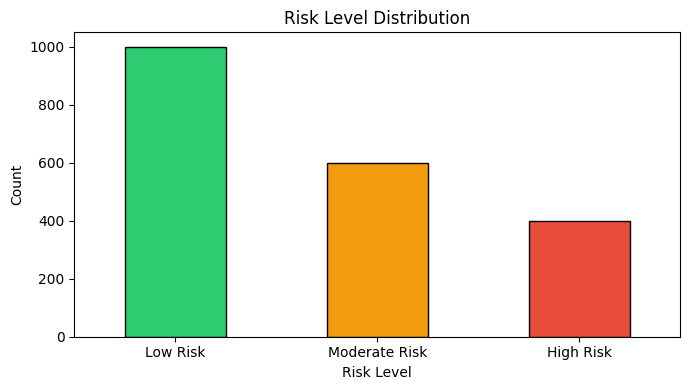

In [178]:
# Step 4 — Explore target distribution
print('Target value counts:')
print(df['risk_level'].value_counts())

df['risk_level'].value_counts().plot(
    kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='black', figsize=(7, 4)
)
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [179]:
# Step 5 — Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
freckles                      516
moles_larger_than_5mm         511
sunburns_in_childhood         491
family_history_skin_cancer    684
dtype: int64


In [180]:
# Step 7 — Define feature groups for encoding

# Numeric feature (no encoding needed)
numeric_features = ['age']

# Ordinal features — categories listed LOW -> HIGH risk order (actual values from dataset)
ordinal_features = {
    'skin_easily_sunburned':       ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
    'tanning_ability':             ['Tans easily and deeply', 'Tans gradually', 'Rarely tans', 'Never tans'],
    'daily_sun_exposure_hours':    ['Less than 1 hour', '1-3 hours', '3-6 hours', 'More than 6 hours'],
    'years_of_tanning_bed_use':    ['Never used', 'Less than 1 year', '1-5 years', 'More than 5 years'],
    'years_lived_in_high_uv_area': ['Never', 'Less than 5 years', '5-15 years', 'More than 15 years'],
    'number_of_moles':             ['0-10', '11-25', '26-50', '51-100', 'More than 100'],
    'sunburns_in_childhood':       ['None', '1-2', '3-5', 'More than 5'],
    'geographic_location_uv':      ['Low UV region', 'Moderate UV region', 'High UV region'],
    # Multi-level ordinal — actual CSV values are NOT Yes/No; moved out of binary group
    'freckles':                    ['None', 'Few', 'Moderate', 'Many'],
    'moles_larger_than_5mm':       ['None', '1-2', '3-5', 'More than 5'],
    'family_history_skin_cancer':  ['None', 'One relative', 'Two or more relatives'],
    'outdoor_work_or_recreation':  ['Rarely', 'Sometimes', 'Often', 'Daily'],
    'use_of_tanning_bed':          ['Never', 'Occasionally', 'Regularly (monthly)', 'Frequently (weekly)'],
    'protective_clothing_worn':    ['Always', 'Usually', 'Sometimes', 'Rarely', 'Never'],
    'perform_skin_self_checks':    ['Monthly', 'Every few months', 'Once a year', 'Rarely', 'Never'],
    'seen_dermatologist':          ['More than once a year', 'Annually', 'Once every few years', 'Never'],
    'diet_high_antioxidants':      ['Often', 'Sometimes', 'Rarely', 'Never'],
}

# Binary Yes/No columns — only genuine Yes/No fields in the dataset
binary_yn_features = [
    'changing_mole_or_lesion', 'new_unusual_skin_growth',
    'severe_blistering_sunburns_ever', 'personal_history_skin_cancer',
    'immunosuppressive_medication', 'autoimmune_disease', 'radiation_therapy_history',
]

# Nominal features — no natural order; one-hot encoded
nominal_features = ['sex', 'skin_tone', 'natural_hair_color', 'eye_color',
                    'use_of_sunscreen', 'smoking_status']

print('Feature groups defined.')
print(f'  Ordinal columns : {list(ordinal_features.keys())}')

Feature groups defined.
  Ordinal columns : ['skin_easily_sunburned', 'tanning_ability', 'daily_sun_exposure_hours', 'years_of_tanning_bed_use', 'years_lived_in_high_uv_area', 'number_of_moles', 'sunburns_in_childhood', 'geographic_location_uv', 'freckles', 'moles_larger_than_5mm', 'family_history_skin_cancer', 'outdoor_work_or_recreation', 'use_of_tanning_bed', 'protective_clothing_worn', 'perform_skin_self_checks', 'seen_dermatologist', 'diet_high_antioxidants']


In [181]:
# Step 8 — Encode features

df_enc = df.copy()

# Drop non-feature identifier column before encoding
df_enc = df_enc.drop(columns=['patient_id'])

# --- Ordinal encoding (preserves order) ---
for col, categories in ordinal_features.items():
    enc = OrdinalEncoder(
        categories=[categories],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )
    df_enc[col] = enc.fit_transform(df_enc[[col]])

# Replace -1 (unknown sentinel) with 0 (lowest category) so no negatives reach the model
for col in ordinal_features.keys():
    df_enc[col] = df_enc[col].clip(lower=0)

# --- Binary Yes/No -> 1/0 ---
for col in binary_yn_features:
    df_enc[col] = df_enc[col].apply(
        lambda v: 1.0 if str(v).strip().lower() == 'yes' else 0.0
    )

# --- Nominal -> one-hot ---
df_enc = pd.get_dummies(df_enc, columns=nominal_features, drop_first=False)

# Force any bool columns (pandas 2.0+) to float
bool_cols = df_enc.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_enc[bool_cols] = df_enc[bool_cols].astype(float)

# --- Encode target ---
target_map = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2}
df_enc['risk_level'] = df_enc['risk_level'].map(target_map)

# --- Sanity check ---
feature_cols = [c for c in df_enc.columns if c != 'risk_level']
print('Encoding complete. Shape:', df_enc.shape)
print('Negative values :', (df_enc[feature_cols] < 0).sum().sum())
print('NaN values      :', df_enc[feature_cols].isnull().sum().sum())
df_enc.head(3)

Encoding complete. Shape: (2000, 52)
Negative values : 0
NaN values      : 0


,age,freckles,number_of_moles,moles_larger_than_5mm,changing_mole_or_lesion,new_unusual_skin_growth,skin_easily_sunburned,tanning_ability,sunburns_in_childhood,severe_blistering_sunburns_ever,...,eye_color_Green,eye_color_Hazel,use_of_sunscreen_Always (SPF 30+),use_of_sunscreen_Never,use_of_sunscreen_Rarely,use_of_sunscreen_Sometimes,use_of_sunscreen_Usually (SPF 15-29),smoking_status_Current,smoking_status_Former,smoking_status_Never
0,58,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,40,3.0,4.0,0.0,1.0,0.0,4.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,35,1.0,1.0,3.0,1.0,1.0,4.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [182]:
# Step 8b — Drop confirmed irrelevant features before splitting

irrelevant_cols = [
    # Eye color — all categories below threshold
    'eye_color_Green', 'eye_color_Blue', 'eye_color_Brown',
    'eye_color_Dark Brown', 'eye_color_Hazel',
    # Skin tone — only drop the low-signal variants; Fair and Olive are kept
    'skin_tone_Dark', 'skin_tone_Medium', 'skin_tone_Brown', 'skin_tone_Very Fair',
    # Natural hair color — only drop the low-signal variants; Black and Red are kept
    'natural_hair_color_Light Brown', 'natural_hair_color_Blonde', 'natural_hair_color_Dark Brown',
    # Smoking status — all categories below threshold
    'smoking_status_Current', 'smoking_status_Former', 'smoking_status_Never',
    # Sex — both categories below threshold
    'sex_Male', 'sex_Female',
    # Sunscreen — only Rarely has signal; all others are noise
    'use_of_sunscreen_Always (SPF 30+)', 'use_of_sunscreen_Never',
    'use_of_sunscreen_Sometimes', 'use_of_sunscreen_Usually (SPF 15-29)',
    # Individual features below threshold
    'autoimmune_disease', 'protective_clothing_worn',
]

cols_to_drop = [c for c in irrelevant_cols if c in df_enc.columns]
df_enc = df_enc.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} irrelevant features.')
print(f'Remaining features : {df_enc.shape[1] - 1}')
print(f'Remaining columns  : {[c for c in df_enc.columns if c != "risk_level"]}')

Dropped 23 irrelevant features.
Remaining features : 28
Remaining columns  : ['age', 'freckles', 'number_of_moles', 'moles_larger_than_5mm', 'changing_mole_or_lesion', 'new_unusual_skin_growth', 'skin_easily_sunburned', 'tanning_ability', 'sunburns_in_childhood', 'severe_blistering_sunburns_ever', 'daily_sun_exposure_hours', 'outdoor_work_or_recreation', 'use_of_tanning_bed', 'years_of_tanning_bed_use', 'personal_history_skin_cancer', 'family_history_skin_cancer', 'immunosuppressive_medication', 'radiation_therapy_history', 'geographic_location_uv', 'years_lived_in_high_uv_area', 'perform_skin_self_checks', 'seen_dermatologist', 'diet_high_antioxidants', 'skin_tone_Fair', 'skin_tone_Olive', 'natural_hair_color_Black', 'natural_hair_color_Red', 'use_of_sunscreen_Rarely']


In [183]:
# Step 9 — Split into train / test sets
X = df_enc.drop(columns=['risk_level']).astype(float).fillna(0.0)
y = df_enc['risk_level'].astype(int)

assert X.isnull().sum().sum() == 0, "NaN still present in X"
assert y.isnull().sum() == 0,       "NaN present in y"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'NaN in X_train   : {X_train.isnull().sum().sum()}')
print(f'Labels           : {sorted(y.unique().tolist())}')

Training samples : 1600
Test samples     : 400
Features         : 28
NaN in X_train   : 0
Labels           : [0, 1, 2]


In [184]:
# Step 10 — Compare multiple models with 5-fold cross-validation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

candidates = {
    'Logistic Regression': LogisticRegression(
        C=0.1, max_iter=2000, class_weight='balanced',
        solver='lbfgs', multi_class='multinomial', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=7, min_samples_leaf=12,
        max_features='sqrt', class_weight='balanced', random_state=42
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=200, max_depth=4, min_samples_leaf=20,
        l2_regularization=1.0, learning_rate=0.05,
        random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f'{"Model":<25} {"CV Mean":>8}   {"CV Std":>8}')
print('-' * 48)
for name, m in candidates.items():
    scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():.4f}   ± {scores.std():.4f}')

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
model = candidates[best_name]
print(f'\nSelected: {best_name}')

Model                      CV Mean     CV Std
------------------------------------------------
Logistic Regression       0.7306   ± 0.0178
Random Forest             0.6444   ± 0.0215
HistGradientBoosting      0.6550   ± 0.0061

Selected: Logistic Regression


In [185]:
# Step 11 — Fit the selected model with probability calibration
# Logistic Regression (and tree models) can output near-0%/100% probabilities
# for extreme patient profiles. CalibratedClassifierCV (Platt scaling) fixes this
# by fitting a sigmoid on top of the raw scores using cross-validation.

from sklearn.calibration import CalibratedClassifierCV

base_model = candidates[best_name]
model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
model.fit(X_train, y_train)
print(f'Model trained with calibration: {best_name}')
print('Calibration method: sigmoid (Platt scaling)')

Model trained with calibration: Logistic Regression
Calibration method: sigmoid (Platt scaling)


In [186]:
# Step 12 — Evaluate on the held-out test set
y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test  Accuracy : {test_acc:.4f}')
print(f'Overfit gap    : {train_acc - test_acc:.4f}  (< 0.05 is acceptable)')

label_names = ['Low Risk', 'Moderate Risk', 'High Risk']
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=label_names))

Train Accuracy : 0.7431
Test  Accuracy : 0.7775
Overfit gap    : -0.0344  (< 0.05 is acceptable)

Classification Report:
               precision    recall  f1-score   support

     Low Risk       0.80      0.95      0.87       200
Moderate Risk       0.73      0.45      0.56       120
    High Risk       0.76      0.84      0.80        80

     accuracy                           0.78       400
    macro avg       0.76      0.75      0.74       400
 weighted avg       0.77      0.78      0.76       400



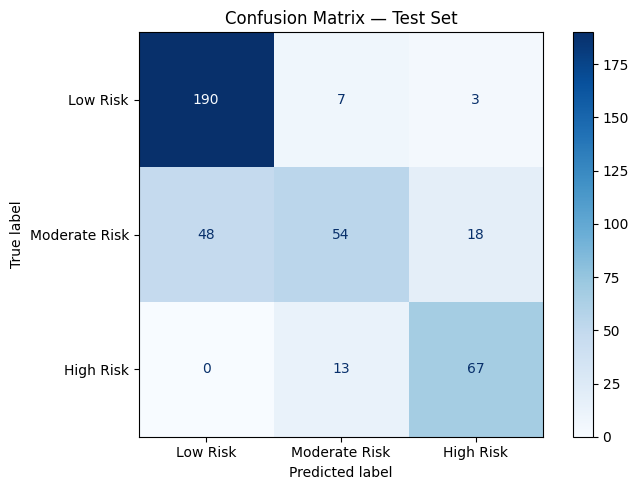

In [187]:
# Step 13 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

Computing permutation importance on test set (takes ~20 seconds)...


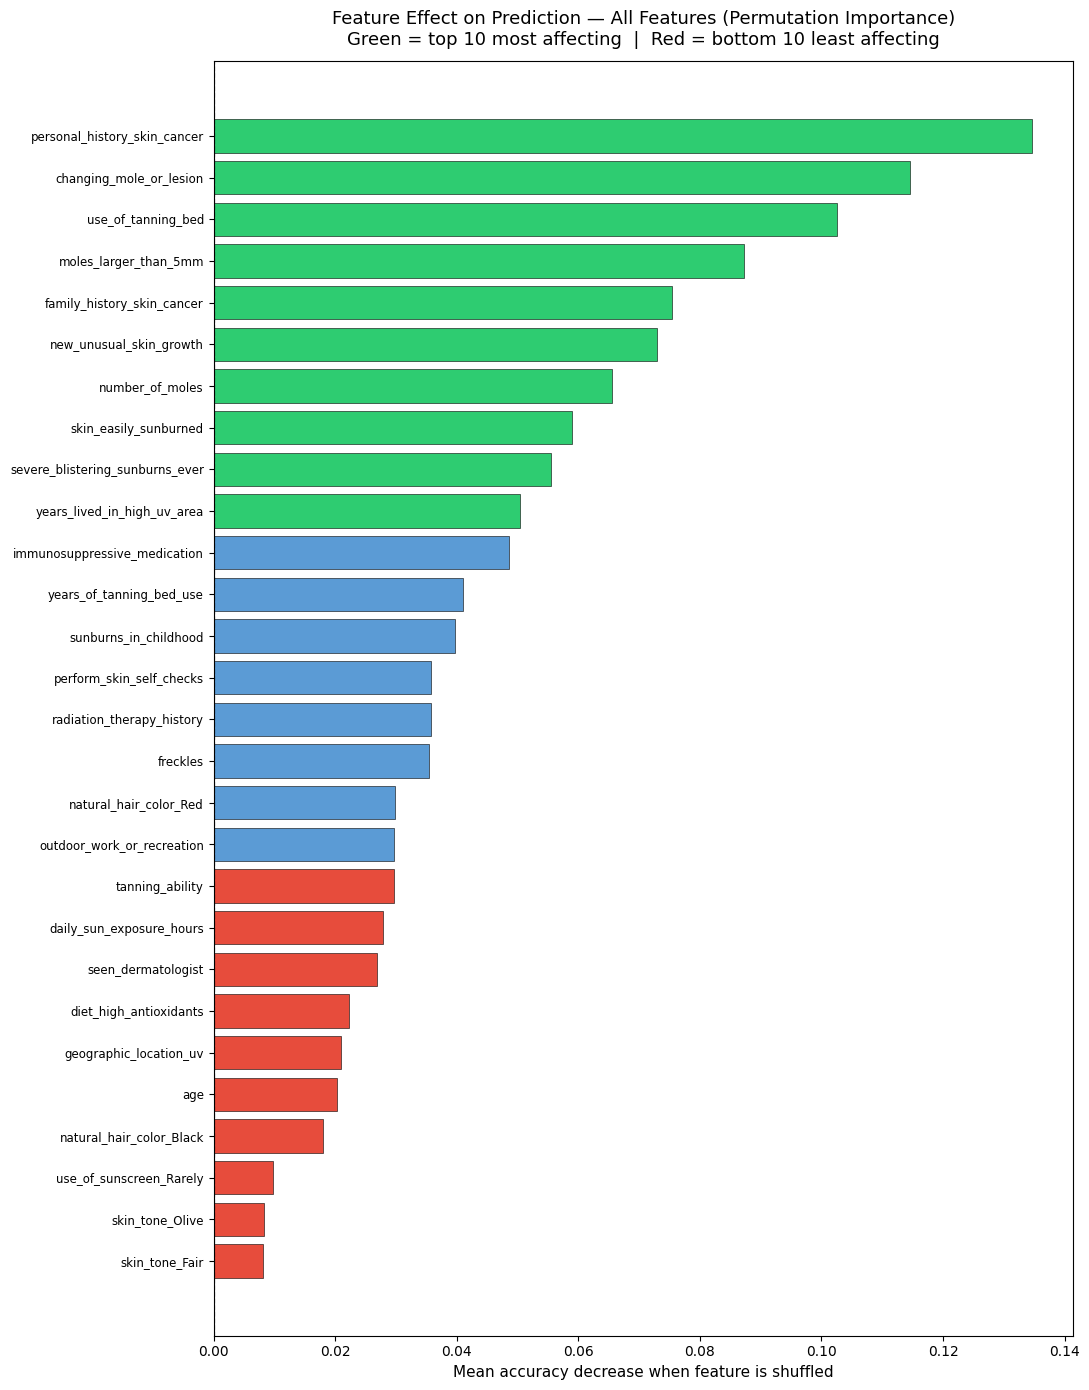


Top 10 MOST affecting features:
----------------------------------------------------
  personal_history_skin_cancer               +0.1347  #############################################################################################################################################################################################################################################################################
  changing_mole_or_lesion                    +0.1145  ####################################################################################################################################################################################################################################
  use_of_tanning_bed                         +0.1025  ############################################################################################################################################################################################################
  moles_larger_than_5mm                      +0.

In [188]:
# Step 14 — Feature Importance: Most & Least Affecting Features
# Permutation importance works with any model (including CalibratedClassifierCV).
# It shuffles one feature at a time and measures how much accuracy drops.
# Bigger drop = feature matters more to the prediction.

from sklearn.inspection import permutation_importance

print('Computing permutation importance on test set (takes ~20 seconds)...')
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=15, random_state=42, scoring='accuracy'
)

importances = pd.Series(perm.importances_mean, index=X.columns).sort_values()
n = len(importances)

# Color: top 10 most affecting = green, bottom 10 least affecting = red, rest = steel blue
colors = ['#e74c3c'] * 10 + ['#5b9bd5'] * (n - 20) + ['#2ecc71'] * 10

fig, ax = plt.subplots(figsize=(11, max(14, n * 0.27)))
ax.barh(importances.index, importances.values, color=colors,
        edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.set_title(
    'Feature Effect on Prediction — All Features (Permutation Importance)\n'
    'Green = top 10 most affecting  |  Red = bottom 10 least affecting',
    fontsize=13, pad=12
)
ax.set_xlabel('Mean accuracy decrease when feature is shuffled', fontsize=11)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.show()

# --- Ranked text summary ---
print('\nTop 10 MOST affecting features:')
print('-' * 52)
for feat, val in importances.tail(10).sort_values(ascending=False).items():
    bar = '#' * max(1, int(val * 2000))
    print(f'  {feat:<42} {val:+.4f}  {bar}')

print('\nBottom 10 LEAST affecting features:')
print('-' * 52)
for feat, val in importances.head(10).items():
    print(f'  {feat:<42} {val:+.4f}')

In [189]:
# Step 14b — Feature Selection: drop ALL features below age's importance score
# (includes the bottom 4 with negative scores — they add noise, not signal)

age_importance = importances['age']

features_to_drop = [
    feat for feat, val in importances.items()
    if val < age_importance
]

print(f'Age importance score : {age_importance:.4f}')
print(f'\nFeatures dropped ({len(features_to_drop)}):')
for f in sorted(features_to_drop):
    print(f'  {f:<45} {importances[f]:+.4f}')

# --- Rebuild X with selected features ---
selected_features = [f for f in X.columns if f not in features_to_drop]
X_sel        = X[selected_features]
X_train_sel  = X_train[selected_features]
X_test_sel   = X_test[selected_features]

print(f'\nFeatures before : {X.shape[1]}')
print(f'Features after  : {X_sel.shape[1]}')

# --- Retrain calibrated model on the reduced feature set ---
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

base_sel  = LogisticRegression(C=0.1, max_iter=2000, class_weight='balanced',
                                solver='lbfgs', multi_class='multinomial', random_state=42)
model_sel = CalibratedClassifierCV(base_sel, method='sigmoid', cv=5)
model_sel.fit(X_train_sel, y_train)

# --- Evaluate ---
y_pred_sel    = model_sel.predict(X_test_sel)
train_acc_sel = accuracy_score(y_train, model_sel.predict(X_train_sel))
test_acc_sel  = accuracy_score(y_test, y_pred_sel)

print(f'\n--- Results after feature selection ---')
print(f'Train Accuracy : {train_acc_sel:.4f}  (was {train_acc:.4f})')
print(f'Test  Accuracy : {test_acc_sel:.4f}  (was {test_acc:.4f})')
print(f'Overfit gap    : {train_acc_sel - test_acc_sel:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_sel, target_names=label_names))

# Overwrite so Step 15 saves the clean model
model   = model_sel
X       = X_sel
X_train = X_train_sel
X_test  = X_test_sel
print('model and X updated — Step 15 will save the selected-feature model.')

Age importance score : 0.0203

Features dropped (4):
  natural_hair_color_Black                      +0.0180
  skin_tone_Fair                                +0.0082
  skin_tone_Olive                               +0.0083
  use_of_sunscreen_Rarely                       +0.0098

Features before : 28
Features after  : 24

--- Results after feature selection ---
Train Accuracy : 0.7406  (was 0.7431)
Test  Accuracy : 0.7525  (was 0.7775)
Overfit gap    : -0.0119

Classification Report:
               precision    recall  f1-score   support

     Low Risk       0.79      0.95      0.86       200
Moderate Risk       0.67      0.39      0.49       120
    High Risk       0.73      0.80      0.76        80

     accuracy                           0.75       400
    macro avg       0.73      0.71      0.71       400
 weighted avg       0.74      0.75      0.73       400

model and X updated — Step 15 will save the selected-feature model.


In [190]:
# Step 15 — Save the calibrated model and the column schema
# The 'model' object here is the full CalibratedClassifierCV wrapper —
# it includes both the base Logistic Regression AND the calibration layer.
joblib.dump(model,           'skin_cancer_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
joblib.dump(target_map,      'target_map.pkl')

print('Calibrated model saved -> skin_cancer_model.pkl')
print('Columns saved          -> feature_columns.pkl')
print('Labels saved           -> target_map.pkl')

Calibrated model saved -> skin_cancer_model.pkl
Columns saved          -> feature_columns.pkl
Labels saved           -> target_map.pkl


In [ ]:
# Step 15b — Re-save pkl files with pickle protocol=4
# Protocol 4 is compatible with Python 3.4+ so Railway (Python 3.11)
# can load models saved on Python 3.13 without KeyError: 239.
import joblib

_model   = joblib.load("skin_cancer_model.pkl")
_cols    = joblib.load("feature_columns.pkl")
_tmap    = joblib.load("target_map.pkl")

joblib.dump(_model, "skin_cancer_model.pkl",  compress=0, protocol=4)
joblib.dump(_cols,  "feature_columns.pkl",    compress=0, protocol=4)
joblib.dump(_tmap,  "target_map.pkl",          compress=0, protocol=4)

print("pkl files re-saved with protocol=4 — compatible with Python 3.11+")

In [191]:
# Step 16 — Helper: build an encoded row from a raw patient dictionary

def encode_new_patient(patient_dict: dict, feature_columns: list) -> pd.DataFrame:
    """
    Applies the same preprocessing pipeline to a new patient dictionary.
    Returns a single-row DataFrame aligned to the training feature columns.
    """
    row = pd.DataFrame([patient_dict])

    # Ordinal encoding — must match exact strings used in training
    ordinal_encoders = {
        'skin_easily_sunburned':       ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
        'tanning_ability':             ['Tans easily and deeply', 'Tans gradually', 'Rarely tans', 'Never tans'],
        'daily_sun_exposure_hours':    ['Less than 1 hour', '1-3 hours', '3-6 hours', 'More than 6 hours'],
        'years_of_tanning_bed_use':    ['Never used', 'Less than 1 year', '1-5 years', 'More than 5 years'],
        'years_lived_in_high_uv_area': ['Never', 'Less than 5 years', '5-15 years', 'More than 15 years'],
        'number_of_moles':             ['0-10', '11-25', '26-50', '51-100', 'More than 100'],
        'sunburns_in_childhood':       ['None', '1-2', '3-5', 'More than 5'],
        'geographic_location_uv':      ['Low UV region', 'Moderate UV region', 'High UV region'],
        'freckles':                    ['None', 'Few', 'Moderate', 'Many'],
        'moles_larger_than_5mm':       ['None', '1-2', '3-5', 'More than 5'],
        'family_history_skin_cancer':  ['None', 'One relative', 'Two or more relatives'],
        'outdoor_work_or_recreation':  ['Rarely', 'Sometimes', 'Often', 'Daily'],
        'use_of_tanning_bed':          ['Never', 'Occasionally', 'Regularly (monthly)', 'Frequently (weekly)'],
        'perform_skin_self_checks':    ['Monthly', 'Every few months', 'Once a year', 'Rarely', 'Never'],
        'seen_dermatologist':          ['More than once a year', 'Annually', 'Once every few years', 'Never'],
        'diet_high_antioxidants':      ['Often', 'Sometimes', 'Rarely', 'Never'],
    }
    for col, cats in ordinal_encoders.items():
        if col in row.columns:
            enc = OrdinalEncoder(categories=[cats], handle_unknown='use_encoded_value', unknown_value=-1)
            row[col] = enc.fit_transform(row[[col]])
            row[col] = row[col].clip(lower=0)

    # Binary Yes/No fields
    bin_cols = [
        'changing_mole_or_lesion', 'new_unusual_skin_growth',
        'severe_blistering_sunburns_ever', 'personal_history_skin_cancer',
        'immunosuppressive_medication', 'radiation_therapy_history',
    ]
    for col in bin_cols:
        if col in row.columns:
            row[col] = row[col].apply(
                lambda v: 1.0 if str(v).strip().lower() == 'yes' else 0.0
            )

    # One-hot encoding for nominal features
    nom_cols = ['skin_tone', 'natural_hair_color', 'use_of_sunscreen']
    row = pd.get_dummies(row, columns=[c for c in nom_cols if c in row.columns], drop_first=False)

    # Cast any booleans to float
    bool_cols = row.select_dtypes(include='bool').columns.tolist()
    if bool_cols:
        row[bool_cols] = row[bool_cols].astype(float)

    # Align to training schema (add missing dummy cols as 0, drop extra)
    row = row.reindex(columns=feature_columns, fill_value=0).astype(float)

    return row

print('Helper function defined.')

Helper function defined.


In [192]:
# Step 18 — Define a new patient and predict their risk level
# Edit the values below to test different patients.

new_patient = {
    # Demographics
    'age'                            : 45,
    'skin_tone'                      : 'Fair',               # Very Fair / Fair / Olive / Brown / Dark
    'natural_hair_color'             : 'Blonde',             # Black / Red / Blonde / Light Brown / Dark Brown

    # Physical traits
    'freckles'                       : 'Moderate',           # None / Few / Moderate / Many
    'number_of_moles'                : '26-50',              # 0-10 / 11-25 / 26-50 / 51-100 / More than 100
    'moles_larger_than_5mm'          : '3-5',                # None / 1-2 / 3-5 / More than 5

    # Symptoms
    'changing_mole_or_lesion'        : 'Yes',                # Yes / No
    'new_unusual_skin_growth'        : 'No',                 # Yes / No

    # Sun exposure
    'skin_easily_sunburned'          : 'Often',              # Never / Rarely / Sometimes / Often / Always
    'tanning_ability'                : 'Rarely tans',        # Tans easily and deeply / Tans gradually / Rarely tans / Never tans
    'sunburns_in_childhood'          : '3-5',                # None / 1-2 / 3-5 / More than 5
    'severe_blistering_sunburns_ever': 'Yes',                # Yes / No
    'daily_sun_exposure_hours'       : '3-6 hours',          # Less than 1 hour / 1-3 hours / 3-6 hours / More than 6 hours
    'outdoor_work_or_recreation'     : 'Daily',              # Rarely / Sometimes / Often / Daily

    # Protection
    'use_of_sunscreen'               : 'Rarely',             # Always (SPF 30+) / Usually (SPF 15-29) / Sometimes / Rarely / Never
    'use_of_tanning_bed'             : 'Never',              # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
    'years_of_tanning_bed_use'       : 'Never used',         # Never used / Less than 1 year / 1-5 years / More than 5 years

    # Medical history
    'personal_history_skin_cancer'   : 'No',                 # Yes / No
    'family_history_skin_cancer'     : 'One relative',       # None / One relative / Two or more relatives
    'immunosuppressive_medication'   : 'No',                 # Yes / No
    'radiation_therapy_history'      : 'No',                 # Yes / No

    # Location
    'geographic_location_uv'         : 'High UV region',     # Low UV region / Moderate UV region / High UV region
    'years_lived_in_high_uv_area'    : '5-15 years',         # Never / Less than 5 years / 5-15 years / More than 15 years

    # Lifestyle
    'perform_skin_self_checks'       : 'Rarely',             # Monthly / Every few months / Once a year / Rarely / Never
    'seen_dermatologist'             : 'Once every few years', # More than once a year / Annually / Once every few years / Never
    'diet_high_antioxidants'         : 'Rarely',             # Often / Sometimes / Rarely / Never
}

import joblib

# Load the saved assets from Step 15
loaded_model   = joblib.load('skin_cancer_model.pkl')
feat_cols      = joblib.load('feature_columns.pkl')
target_map     = joblib.load('target_map.pkl')
inv_target_map = {v: k for k, v in target_map.items()}

# Encode and predict
patient_row     = encode_new_patient(new_patient, feat_cols)
predicted_code  = loaded_model.predict(patient_row)[0]
predicted_label = inv_target_map[predicted_code]
proba           = loaded_model.predict_proba(patient_row)[0]

print('=' * 45)
print(f'  Predicted Risk Level : {predicted_label}')
print('=' * 45)
print('\nClass Probabilities:')
for code, label in sorted(inv_target_map.items()):
    print(f'  {label:<18}: {proba[code]*100:.1f}%')

  Predicted Risk Level : Low Risk

Class Probabilities:
  Low Risk          : 60.6%
  Moderate Risk     : 35.6%
  High Risk         : 3.9%


In [193]:
# Step 19 — Batch prediction for multiple new patients

batch_patients = [
    {   # Low-risk profile
        'age': 28,
        'skin_tone': 'Dark',                       # Very Fair / Fair / Olive / Brown / Dark
        'natural_hair_color': 'Black',             # Black / Red / Blonde / Light Brown / Dark Brown
        'freckles': 'None',                        # None / Few / Moderate / Many
        'number_of_moles': '0-10',                 # 0-10 / 11-25 / 26-50 / 51-100 / More than 100
        'moles_larger_than_5mm': 'None',           # None / 1-2 / 3-5 / More than 5
        'changing_mole_or_lesion': 'No',
        'new_unusual_skin_growth': 'No',
        'skin_easily_sunburned': 'Never',          # Never / Rarely / Sometimes / Often / Always
        'tanning_ability': 'Tans easily and deeply',
        'sunburns_in_childhood': 'None',           # None / 1-2 / 3-5 / More than 5
        'severe_blistering_sunburns_ever': 'No',
        'daily_sun_exposure_hours': 'Less than 1 hour',
        'outdoor_work_or_recreation': 'Rarely',    # Rarely / Sometimes / Often / Daily
        'use_of_sunscreen': 'Always (SPF 30+)',    # Always (SPF 30+) / Usually (SPF 15-29) / Sometimes / Rarely / Never
        'use_of_tanning_bed': 'Never',             # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
        'years_of_tanning_bed_use': 'Never used',  # Never used / Less than 1 year / 1-5 years / More than 5 years
        'personal_history_skin_cancer': 'No',
        'family_history_skin_cancer': 'None',      # None / One relative / Two or more relatives
        'immunosuppressive_medication': 'No',
        'radiation_therapy_history': 'No',
        'geographic_location_uv': 'Low UV region', # Low UV region / Moderate UV region / High UV region
        'years_lived_in_high_uv_area': 'Never',    # Never / Less than 5 years / 5-15 years / More than 15 years
        'perform_skin_self_checks': 'Monthly',     # Monthly / Every few months / Once a year / Rarely / Never
        'seen_dermatologist': 'Annually',          # More than once a year / Annually / Once every few years / Never
        'diet_high_antioxidants': 'Often',         # Often / Sometimes / Rarely / Never
    },
    {   # High-risk profile
        'age': 62,
        'skin_tone': 'Very Fair',                  # Very Fair / Fair / Olive / Brown / Dark
        'natural_hair_color': 'Red',               # Black / Red / Blonde / Light Brown / Dark Brown
        'freckles': 'Many',                        # None / Few / Moderate / Many
        'number_of_moles': '51-100',               # 0-10 / 11-25 / 26-50 / 51-100 / More than 100
        'moles_larger_than_5mm': 'More than 5',    # None / 1-2 / 3-5 / More than 5
        'changing_mole_or_lesion': 'Yes',
        'new_unusual_skin_growth': 'Yes',
        'skin_easily_sunburned': 'Always',         # Never / Rarely / Sometimes / Often / Always
        'tanning_ability': 'Never tans',
        'sunburns_in_childhood': 'More than 5',    # None / 1-2 / 3-5 / More than 5
        'severe_blistering_sunburns_ever': 'Yes',
        'daily_sun_exposure_hours': 'More than 6 hours',
        'outdoor_work_or_recreation': 'Daily',     # Rarely / Sometimes / Often / Daily
        'use_of_sunscreen': 'Never',               # Always (SPF 30+) / Usually (SPF 15-29) / Sometimes / Rarely / Never
        'use_of_tanning_bed': 'Frequently (weekly)', # Never / Occasionally / Regularly (monthly) / Frequently (weekly)
        'years_of_tanning_bed_use': 'More than 5 years',
        'personal_history_skin_cancer': 'Yes',
        'family_history_skin_cancer': 'Two or more relatives',
        'immunosuppressive_medication': 'Yes',
        'radiation_therapy_history': 'Yes',
        'geographic_location_uv': 'High UV region',
        'years_lived_in_high_uv_area': 'More than 15 years',
        'perform_skin_self_checks': 'Never',       # Monthly / Every few months / Once a year / Rarely / Never
        'seen_dermatologist': 'Never',             # More than once a year / Annually / Once every few years / Never
        'diet_high_antioxidants': 'Never',         # Often / Sometimes / Rarely / Never
    }
]

print(f'Batch predicting {len(batch_patients)} patients...\n')
for i, patient in enumerate(batch_patients, 1):
    row         = encode_new_patient(patient, feat_cols)
    code        = loaded_model.predict(row)[0]
    label       = inv_target_map[code]
    proba_batch = loaded_model.predict_proba(row)[0]
    print(f'Patient {i} (age {patient["age"]}): {label}')
    for c, l in sorted(inv_target_map.items()):
        print(f'   {l:<18}: {proba_batch[c]*100:.1f}%')
    print()

Batch predicting 2 patients...

Patient 1 (age 28): Low Risk
   Low Risk          : 78.5%
   Moderate Risk     : 21.5%
   High Risk         : 0.0%

Patient 2 (age 62): High Risk
   Low Risk          : 0.0%
   Moderate Risk     : 24.9%
   High Risk         : 75.1%

